<a href="https://colab.research.google.com/github/Abi-ijlan/Panda_study/blob/main/base_line.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# ── Segment split ─────────────────────────────────────────────────────────────
total_segments  = 2522


typical_segments = 2000   # ~1892
pier_ej_segments = 522   # ~630

# ── Cycle times ───────────────────────────────────────────────────────────────
typical_cycle_hrs = 40
pier_ej_cycle_hrs = 68

# ── Shift basis ───────────────────────────────────────────────────────────────
shift_hrs_per_day = 20

# ── Mould ramp-up ─────────────────────────────────────────────────────────────
moulds_per_batch  = 3       # moulds added every ramp-up period
ramp_up_months    = 1.5     # months between each batch
total_moulds      = 13
typical_moulds    = 10      # first to come online
pier_moulds       = 3       # come online after all typical moulds

print(f"Typical segments : {typical_segments}")
print(f"Pier/EJ segments : {pier_ej_segments}")
print(f"Total            : {typical_segments + pier_ej_segments}")

Typical segments : 2000
Pier/EJ segments : 522
Total            : 2522


In [2]:
# ── Days per month ────────────────────────────────────────────────────────────
days_per_month = 30

# ── Available hours per mould per month ──────────────────────────────────────
hours_per_month = days_per_month * shift_hrs_per_day   # 30 × 20 = 600 hrs

# ── Segments per mould per month ─────────────────────────────────────────────
typical_per_mould_month = hours_per_month / typical_cycle_hrs   # 600 / 40 = 15
pier_per_mould_month    = hours_per_month / pier_ej_cycle_hrs   # 600 / 68 ≈ 8.8

print(f"Hours available per mould per month : {hours_per_month} hrs")
print(f"Typical segments per mould/month    : {typical_per_mould_month:.1f}")
print(f"Pier/EJ segments per mould/month    : {pier_per_mould_month:.1f}")

Hours available per mould per month : 600 hrs
Typical segments per mould/month    : 15.0
Pier/EJ segments per mould/month    : 8.8


In [3]:
# ── Ramp-up schedule ─────────────────────────────────────────────────────────
# Typical moulds come online first (3 every 1.5 months)
# After all typical moulds, pier moulds come online

ramp_schedule = []

active_typical = 0
active_pier    = 0
month          = 0

# Add typical moulds first
while active_typical < typical_moulds:
    active_typical = min(active_typical + moulds_per_batch, typical_moulds)
    ramp_schedule.append({
        'Month'          : month,
        'Active_Typical' : active_typical,
        'Active_Pier'    : active_pier
    })
    month += ramp_up_months

# Then add pier moulds
while active_pier < pier_moulds:
    active_pier = min(active_pier + moulds_per_batch, pier_moulds)
    ramp_schedule.append({
        'Month'          : month,
        'Active_Typical' : active_typical,
        'Active_Pier'    : active_pier
    })
    month += ramp_up_months

df_ramp = pd.DataFrame(ramp_schedule)
print(df_ramp)

   Month  Active_Typical  Active_Pier
0    0.0               3            0
1    1.5               6            0
2    3.0               9            0
3    4.5              10            0
4    6.0              10            3


In [15]:
# ── Generate month-by-month production ───────────────────────────────────────
timeline = []

cumulative_typical = 0
cumulative_pier    = 0
month_num          = 0

while cumulative_typical < typical_segments or cumulative_pier < pier_ej_segments:

    # Find active moulds for this month based on ramp-up schedule
    ramp_now = df_ramp[df_ramp['Month'] <= month_num].iloc[-1]
    active_typical_now = ramp_now['Active_Typical']
    active_pier_now    = ramp_now['Active_Pier']

    # Raw output this month
    typical_output = active_typical_now * typical_per_mould_month
    pier_output    = active_pier_now    * pier_per_mould_month

    # Cap at remaining segments
    typical_output = min(typical_output, typical_segments - cumulative_typical)
    pier_output    = min(pier_output,    pier_ej_segments - cumulative_pier)

    cumulative_typical += typical_output
    cumulative_pier    += pier_output

    timeline.append({
        'Month'              : month_num + 1,
        'Active_Typical'     : int(active_typical_now),
        'Active_Pier'        : int(active_pier_now),
        'Typical_Output'     : round(typical_output, 1),
        'Pier_Output'        : round(pier_output, 1),
        'Total_Output'       : round(typical_output + pier_output, 1),
        'Cumulative_Typical' : round(cumulative_typical, 1),
        'Cumulative_Pier'    : round(cumulative_pier, 1),
        'Cumulative_Total'   : round(cumulative_typical + cumulative_pier, 1)
    })

    month_num += 1

df_timeline = pd.DataFrame(timeline)
print(df_timeline.to_string(index=False))
print(f"\nProject(precasting) completes in {month_num} months")

 Month  Active_Typical  Active_Pier  Typical_Output  Pier_Output  Total_Output  Cumulative_Typical  Cumulative_Pier  Cumulative_Total
     1               3            0            45.0          0.0          45.0                45.0              0.0              45.0
     2               3            0            45.0          0.0          45.0                90.0              0.0              90.0
     3               6            0            90.0          0.0          90.0               180.0              0.0             180.0
     4               9            0           135.0          0.0         135.0               315.0              0.0             315.0
     5               9            0           135.0          0.0         135.0               450.0              0.0             450.0
     6              10            0           150.0          0.0         150.0               600.0              0.0             600.0
     7              10            3           150.0         26

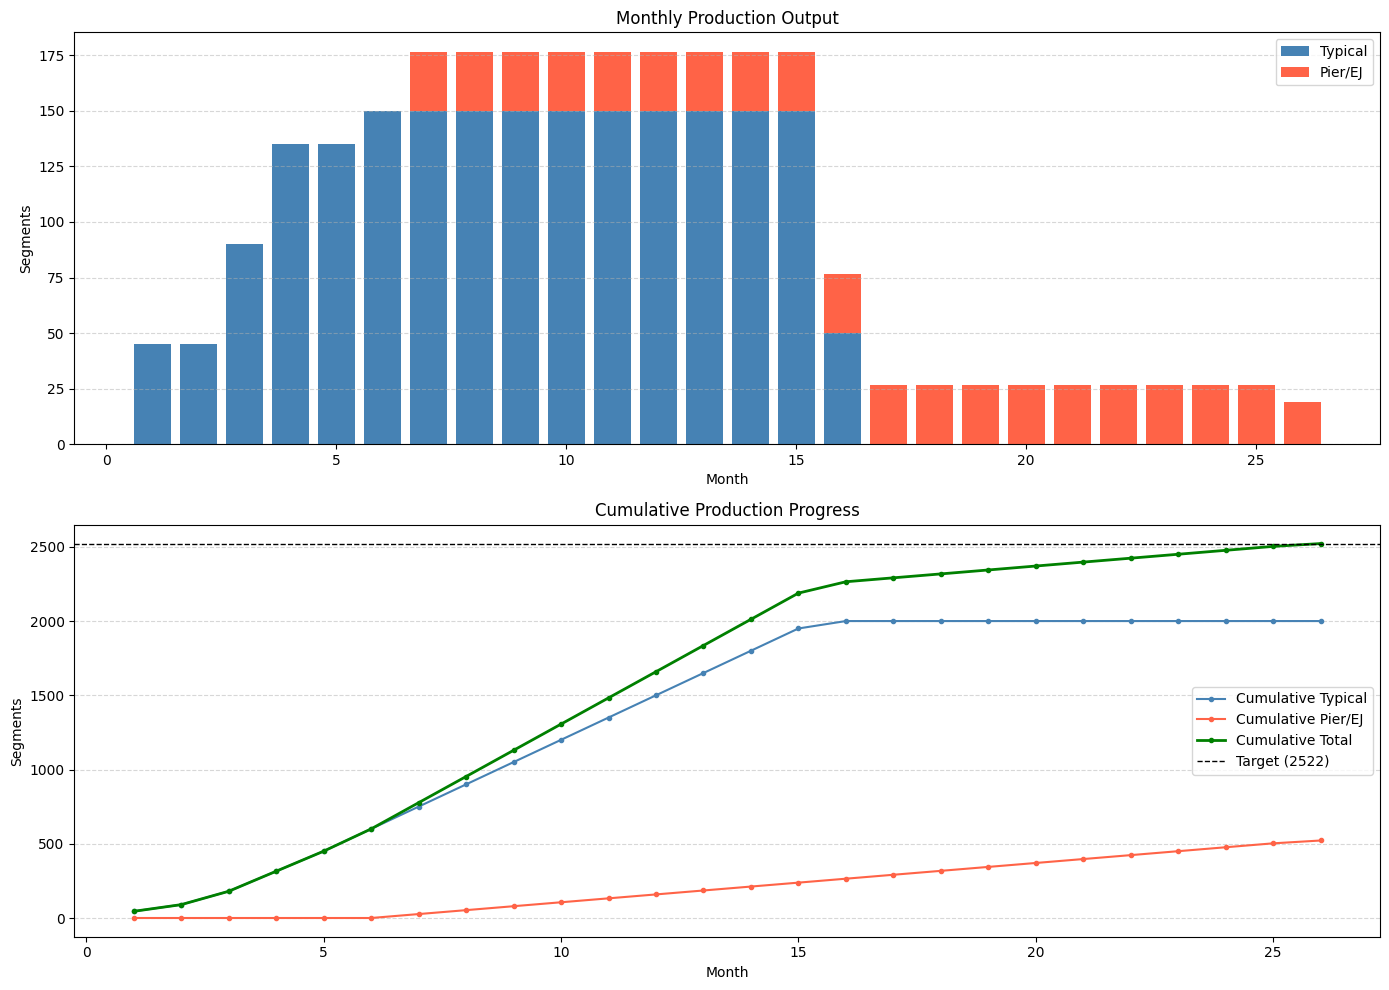


Base plan completes in 26 months


In [5]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ── Chart 1: Monthly Production (stacked bar) ─────────────────────────────────
ax1.bar(df_timeline['Month'], df_timeline['Typical_Output'],
        label='Typical', color='steelblue')
ax1.bar(df_timeline['Month'], df_timeline['Pier_Output'],
        bottom=df_timeline['Typical_Output'],
        label='Pier/EJ', color='tomato')

ax1.set_xlabel('Month')
ax1.set_ylabel('Segments')
ax1.set_title('Monthly Production Output')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# ── Chart 2: Cumulative Production (line) ─────────────────────────────────────
ax2.plot(df_timeline['Month'], df_timeline['Cumulative_Typical'],
         label='Cumulative Typical', color='steelblue', marker='o', markersize=3)
ax2.plot(df_timeline['Month'], df_timeline['Cumulative_Pier'],
         label='Cumulative Pier/EJ', color='tomato', marker='o', markersize=3)
ax2.plot(df_timeline['Month'], df_timeline['Cumulative_Total'],
         label='Cumulative Total', color='green', linewidth=2, marker='o', markersize=3)

# Target line
ax2.axhline(y=total_segments, color='black', linestyle='--', linewidth=1, label='Target (2522)')

ax2.set_xlabel('Month')
ax2.set_ylabel('Segments')
ax2.set_title('Cumulative Production Progress')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('base_plan.png', dpi=150)
plt.show()

print(f"\nBase plan completes in {month_num} months")

In [6]:
# ── Define scenarios ──────────────────────────────────────────────────────────
# Each scenario has:
#   - name        : scenario label
#   - start_month : when delay begins (1-indexed)
#   - duration    : how many months the delay lasts
#   - moulds_down : how many moulds are affected
#   - mould_type  : 'typical', 'pier', or 'all'

# ── Define scenarios ──────────────────────────────────────────────────────────
scenarios = [
    {'name': 'Mould Breakdown',     'start_month': 3,  'duration': 1,   'moulds_down': 2,  'mould_type': 'typical'},
    {'name': 'Concrete Disruption', 'start_month': 6,  'duration': 0.5, 'moulds_down': 13, 'mould_type': 'all'},
    {'name': 'Monsoon Slowdown',    'start_month': 8,  'duration': 2,   'moulds_down': 5,  'mould_type': 'typical'},
    {'name': 'Design Hold',         'start_month': 12, 'duration': 1,   'moulds_down': 3,  'mould_type': 'pier'},
    {'name': 'Labour Strike',       'start_month': 15, 'duration': 0.5, 'moulds_down': 13, 'mould_type': 'all'},
]

# ── Labour charges ────────────────────────────────────────────────────────────────
#idle_cost_per_mould_per_day = 10000        # ₹/day — same for all mould types
labour_cost_per_day         = 400 * shift_hrs_per_day   # ₹400/hr × 20 hrs

#print(f"Idle cost per mould per day : ₹{idle_cost_per_mould_per_day:,}")
print(f"Labour standby cost per day : ₹{labour_cost_per_day:,}")
print()
print("Scenarios defined:")
for s in scenarios:
    print(f"  {s['name']:25s} | Month {s['start_month']} | {s['duration']} month(s) | {s['moulds_down']} moulds down ({s['mould_type']})")

Idle cost per mould per day : ₹10,000
Labour standby cost per day : ₹8,000

Scenarios defined:
  Mould Breakdown           | Month 3 | 1 month(s) | 2 moulds down (typical)
  Concrete Disruption       | Month 6 | 0.5 month(s) | 13 moulds down (all)
  Monsoon Slowdown          | Month 8 | 2 month(s) | 5 moulds down (typical)
  Design Hold               | Month 12 | 1 month(s) | 3 moulds down (pier)
  Labour Strike             | Month 15 | 0.5 month(s) | 13 moulds down (all)


In [21]:
# ── Early detection time by RFID (in hours) ───────────────────────────────────
early_detection_hrs = {
    'Mould Breakdown'     : 3.5,
    'Concrete Disruption' : 1.5,
    'Monsoon Slowdown'    : 22,
    'Design Hold'         : 46,
    'Labour Strike'       : 1.5,
}

# ── Simulate each scenario ────────────────────────────────────────────────────
results = []

for s in scenarios:
    duration_days   = s['duration'] * days_per_month
    moulds_down     = s['moulds_down']

    # Lost production
    if s['mould_type'] == 'typical':
        lost_segments = moulds_down * typical_per_mould_month * s['duration']
    elif s['mould_type'] == 'pier':
        lost_segments = moulds_down * pier_per_mould_month * s['duration']
    else:  # all
        lost_typical  = min(moulds_down, typical_moulds) * typical_per_mould_month * s['duration']
        lost_pier     = max(0, moulds_down - typical_moulds) * pier_per_mould_month * s['duration']
        lost_segments = lost_typical + lost_pier

    # Timeline delay
    # How many extra months needed to recover lost segments at full capacity
    full_capacity     = (typical_moulds * typical_per_mould_month) + (pier_moulds * pier_per_mould_month)
    delay_months      = lost_segments / full_capacity

    # Idle cost (removed as per user request)

    # Labour standby cost
    labour_cost       = duration_days * labour_cost_per_day

    # Total cost without RFID (now only includes labour cost)
    total_cost        = labour_cost

    # RFID saving - now based on labour cost, as idle cost is removed, and includes moulds_down
    detect_hrs        = early_detection_hrs[s['name']]
    rfid_saving       = moulds_down * (detect_hrs / 24) * labour_cost_per_day

    # Net cost with RFID
    net_cost_rfid     = total_cost - rfid_saving

    results.append({
        'Scenario'          : s['name'],
        'Duration (months)' : s['duration'],
        'Moulds Down'       : moulds_down,
        'Lost Segments'     : round(lost_segments, 1),
        'Delay (months)'    : round(delay_months, 2),
        'Labour Cost (₹)'   : round(labour_cost),
        'Total Cost (₹)'    : round(total_cost),
        'RFID Saving (₹)'   : round(rfid_saving),
        'Net Cost RFID (₹)' : round(net_cost_rfid),
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nTotal lost segments(could have been)  : {df_results['Lost Segments'].sum():.1f}")
print(f"Total labour cost      : ₹{df_results['Total Cost (₹)'].sum():,.0f}")
print(f"Total RFID saving    : ₹{df_results['RFID Saving (₹)'].sum():,.0f}")
print(f"Net cost with RFID(have to bear)   : ₹{df_results['Net Cost RFID (₹)'].sum():,.0f}")

           Scenario  Duration (months)  Moulds Down  Lost Segments  Delay (months)  Labour Cost (₹)  Total Cost (₹)  RFID Saving (₹)  Net Cost RFID (₹)
    Mould Breakdown                1.0            2           30.0            0.17           240000          240000             2333             237667
Concrete Disruption                0.5           13           88.2            0.50           120000          120000             6500             113500
   Monsoon Slowdown                2.0            5          150.0            0.85           480000          480000            36667             443333
        Design Hold                1.0            3           26.5            0.15           240000          240000            46000             194000
      Labour Strike                0.5           13           88.2            0.50           120000          120000             6500             113500

Total lost segments(could have been)  : 382.9
Total labour cost      : ₹1,200,000
Total

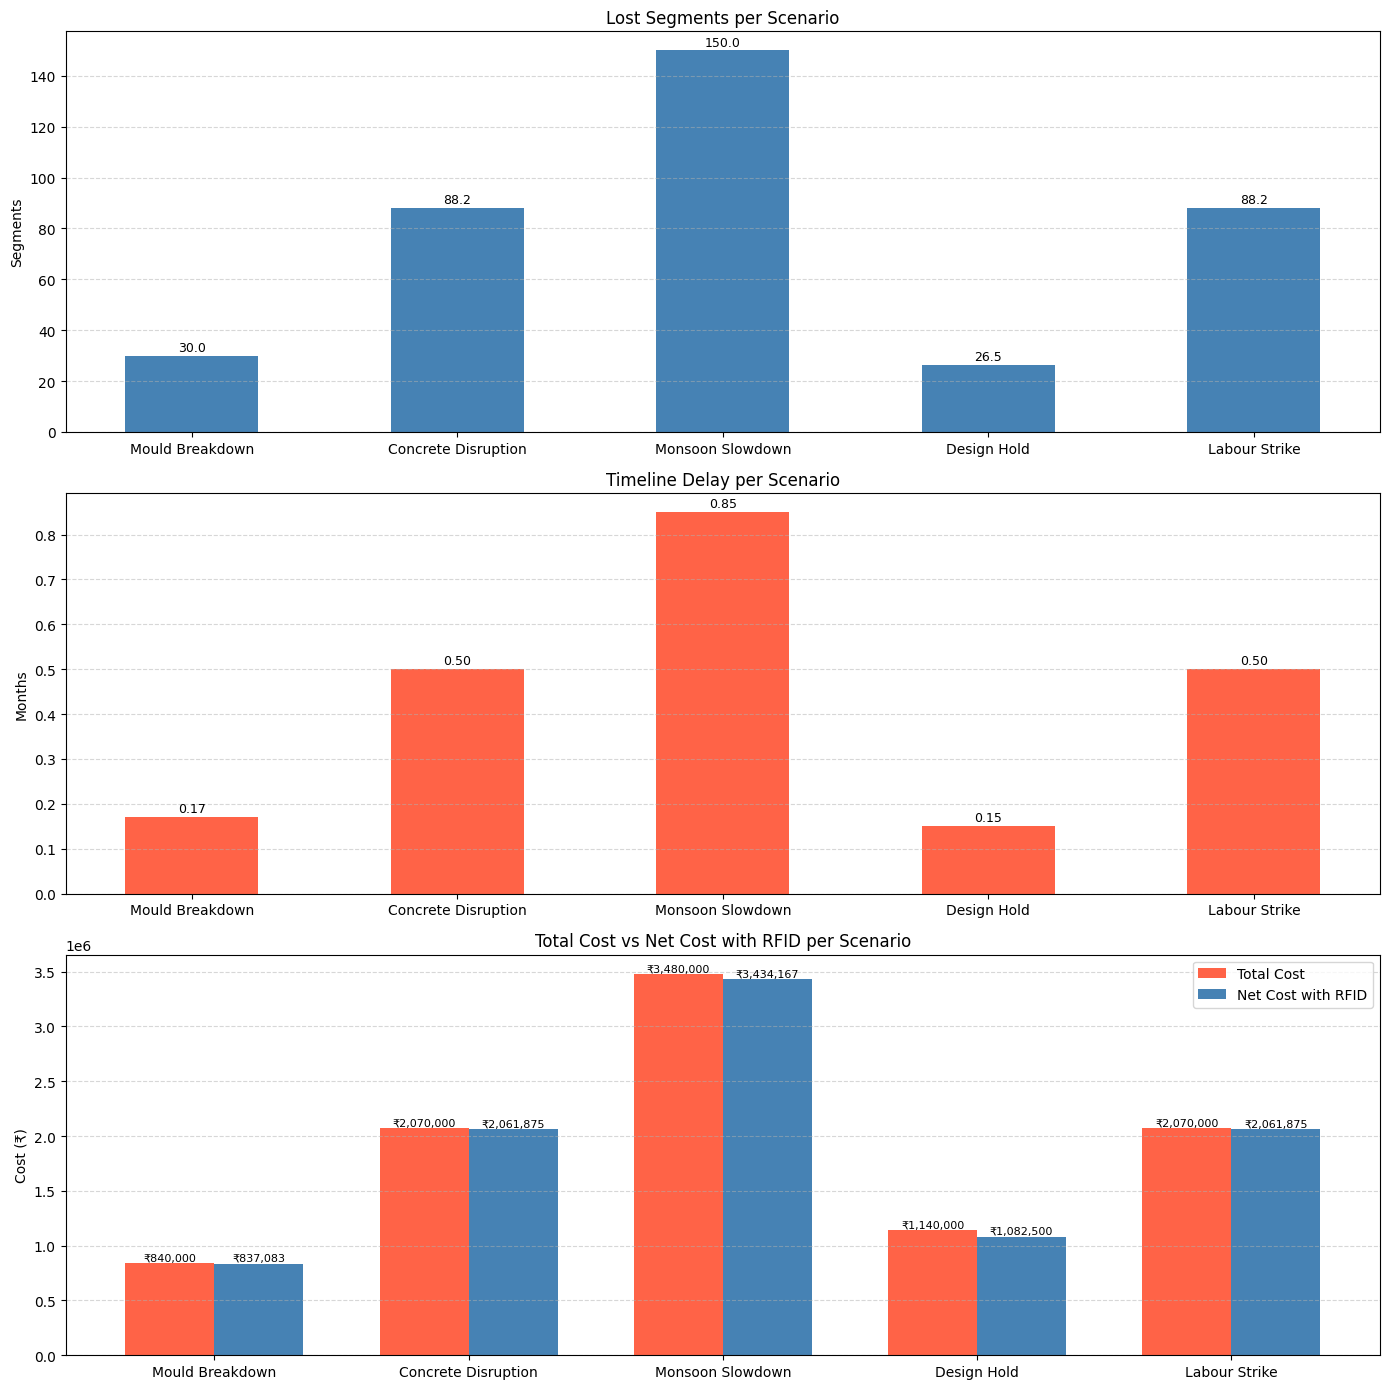

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

scenarios_list = df_results['Scenario'].tolist()
x              = np.arange(len(scenarios_list))
width          = 0.35

# ── Chart 1: Lost Segments per Scenario ──────────────────────────────────────
axes[0].bar(x, df_results['Lost Segments'], color='steelblue', width=0.5)
for i, v in enumerate(df_results['Lost Segments']):
    axes[0].text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(scenarios_list, rotation=0, ha='center')
axes[0].set_ylabel('Segments')
axes[0].set_title('Lost Segments per Scenario')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# ── Chart 2: Delay in Months per Scenario ────────────────────────────────────
axes[1].bar(x, df_results['Delay (months)'], color='tomato', width=0.5)
for i, v in enumerate(df_results['Delay (months)']):
    axes[1].text(i, v + 0.005, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(scenarios_list, rotation=0, ha='center')
axes[1].set_ylabel('Months')
axes[1].set_title('Timeline Delay per Scenario')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# ── Chart 3: Cost Comparison — Total vs Net RFID ─────────────────────────────
bars_total = axes[2].bar(x - width/2, df_results['Total Cost (₹)'],
                         width, label='Total Cost', color='tomato')
bars_rfid  = axes[2].bar(x + width/2, df_results['Net Cost RFID (₹)'],
                         width, label='Net Cost with RFID', color='steelblue')

for bar in bars_total:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)
for bar in bars_rfid:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

axes[2].set_xticks(x)
axes[2].set_xticklabels(scenarios_list, rotation=0, ha='center')
axes[2].set_ylabel('Cost (₹)')
axes[2].set_title('Total Cost vs Net Cost with RFID per Scenario')
axes[2].legend()
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('scenario_analysis.png', dpi=150)
plt.show()

In [9]:
# ── Liquidated Damages Calculation ───────────────────────────────────────────
ld_upper_cap = 20000000  # ₹200 Cr = ₹20,00,00,000

def calculate_ld(delay_days):
    ld = 0

    if delay_days <= 0:
        return 0

    # First 28 days — ₹10,000/day
    slab1_days = min(delay_days, 28)
    ld += slab1_days * 10000

    # Days 29–56 — ₹50,000/day
    if delay_days > 28:
        slab2_days = min(delay_days - 28, 28)
        ld += slab2_days * 50000

    # Day 57 onwards — ₹1,00,000/day
    if delay_days > 56:
        slab3_days = delay_days - 56
        ld += slab3_days * 100000

    # Apply upper cap
    ld = min(ld, ld_upper_cap)

    return ld

# ── Apply to each scenario ────────────────────────────────────────────────────
df_results['Delay (days)']  = (df_results['Delay (months)'] * days_per_month).round(1)
df_results['LD Cost (₹)']   = df_results['Delay (days)'].apply(lambda x: calculate_ld(int(x)))

# ── Updated Total Cost ────────────────────────────────────────────────────────
df_results['Total Cost with LD (₹)'] = df_results['Total Cost (₹)'] + df_results['LD Cost (₹)']

# ── Print updated results ─────────────────────────────────────────────────────
print(df_results[['Scenario', 'Delay (days)', 'LD Cost (₹)',
                   'Total Cost (₹)', 'Total Cost with LD (₹)']].to_string(index=False))

print(f"\nTotal LD Cost         : ₹{df_results['LD Cost (₹)'].sum():,.0f}")
print(f"Total Cost with LD    : ₹{df_results['Total Cost with LD (₹)'].sum():,.0f}")

           Scenario  Delay (days)  LD Cost (₹)  Total Cost (₹)  Total Cost with LD (₹)
    Mould Breakdown           5.1        50000          840000                  890000
Concrete Disruption          15.0       150000         2070000                 2220000
   Monsoon Slowdown          25.5       250000         3480000                 3730000
        Design Hold           4.5        40000         1140000                 1180000
      Labour Strike          15.0       150000         2070000                 2220000

Total LD Cost         : ₹640,000
Total Cost with LD    : ₹10,240,000


In [10]:
# ── RFID reduced delay days ───────────────────────────────────────────────────
df_results['RFID Detection Saving (days)'] = df_results['Scenario'].map(
    {s: early_detection_hrs[s] / 24 for s in early_detection_hrs}
)

df_results['Delay (days) with RFID'] = (df_results['Delay (days)'] -
                                         df_results['RFID Detection Saving (days)']).clip(lower=0).round(1)

# ── LD with and without RFID ──────────────────────────────────────────────────
df_results['LD Cost (₹)']           = df_results['Delay (days)'].apply(lambda x: calculate_ld(int(x)))
df_results['LD Cost with RFID (₹)'] = df_results['Delay (days) with RFID'].apply(lambda x: calculate_ld(int(x)))

# ── LD saving due to RFID ─────────────────────────────────────────────────────
df_results['LD Saving by RFID (₹)'] = df_results['LD Cost (₹)'] - df_results['LD Cost with RFID (₹)']

# ── Print ─────────────────────────────────────────────────────────────────────
print(df_results[['Scenario', 'Delay (days)', 'LD Cost (₹)',
                   'Delay (days) with RFID', 'LD Cost with RFID (₹)',
                   'LD Saving by RFID (₹)']].to_string(index=False))

print(f"\nTotal LD without RFID : ₹{df_results['LD Cost (₹)'].sum():,.0f}")
print(f"Total LD with RFID    : ₹{df_results['LD Cost with RFID (₹)'].sum():,.0f}")
print(f"Total LD Saving       : ₹{df_results['LD Saving by RFID (₹)'].sum():,.0f}")

           Scenario  Delay (days)  LD Cost (₹)  Delay (days) with RFID  LD Cost with RFID (₹)  LD Saving by RFID (₹)
    Mould Breakdown           5.1        50000                     5.0                  50000                      0
Concrete Disruption          15.0       150000                    14.9                 140000                  10000
   Monsoon Slowdown          25.5       250000                    24.6                 240000                  10000
        Design Hold           4.5        40000                     2.6                  20000                  20000
      Labour Strike          15.0       150000                    14.9                 140000                  10000

Total LD without RFID : ₹640,000
Total LD with RFID    : ₹590,000
Total LD Saving       : ₹50,000


In [12]:
# ── Project parameters ────────────────────────────────────────────────────────
total_project_budget_cr  = 2000                          # ₹ Crore
total_project_budget     = total_project_budget_cr * 1e7 # ₹ 2,00,00,00,000

project_duration_months  = month_num                     # from base plan simulation
project_duration_days    = project_duration_months * days_per_month

site_overhead_pct        = 0.10                          # 10% of total project cost

# ── Total site overhead over project duration ─────────────────────────────────
total_site_overhead      = total_project_budget * site_overhead_pct

# ── Daily site overhead for entire yard ──────────────────────────────────────
daily_site_overhead      = total_site_overhead / project_duration_days

# ── Per mould per day (prorated across 13 moulds) ────────────────────────────
site_overhead_per_mould_per_day = daily_site_overhead / total_moulds

print(f"Total project budget             : ₹{total_project_budget_cr} Cr")
print(f"Site overhead (10%)              : ₹{total_site_overhead/1e7:.1f} Cr")
print(f"Project duration                 : {project_duration_days:.0f} days")
print(f"Daily site overhead (yard)       : ₹{daily_site_overhead:,.0f}")
print(f"Site overhead per mould per day  : ₹{site_overhead_per_mould_per_day:,.0f}")

# ── RFID saving on site overhead ─────────────────────────────────────────────
df_results['Site Overhead per day (₹)'] = site_overhead_per_mould_per_day * df_results['Moulds Down']

df_results['Site Overhead Cost (₹)']    = (df_results['Site Overhead per day (₹)'] *
                                            df_results['Delay (days)'])

df_results['Site Overhead with RFID (₹)'] = (df_results['Site Overhead per day (₹)'] *
                                              df_results['Delay (days) with RFID'])

df_results['Site Overhead Saving by RFID (₹)'] = (df_results['Site Overhead Cost (₹)'] -
                                                    df_results['Site Overhead with RFID (₹)'])

# ── Updated total cost including site overhead ────────────────────────────────
df_results['Total Cost with OH (₹)']      = (df_results['Total Cost (₹)'] +
                                              df_results['Site Overhead Cost (₹)'])

df_results['Total Cost with OH RFID (₹)'] = (df_results['Net Cost RFID (₹)'] +
                                              df_results['Site Overhead with RFID (₹)'])

df_results['Total OH Saving by RFID (₹)'] = (df_results['Total Cost with OH (₹)'] -
                                              df_results['Total Cost with OH RFID (₹)'])

# ── Print summary ─────────────────────────────────────────────────────────────
print(df_results[['Scenario',
                   'Site Overhead Cost (₹)',
                   'Site Overhead with RFID (₹)',
                   'Site Overhead Saving by RFID (₹)',
                   'Total Cost with OH (₹)',
                   'Total Cost with OH RFID (₹)',
                   'Total OH Saving by RFID (₹)']].to_string(index=False))

print(f"\nTotal Site Overhead Cost         : ₹{df_results['Site Overhead Cost (₹)'].sum():,.0f}")
print(f"Total Site Overhead with RFID    : ₹{df_results['Site Overhead with RFID (₹)'].sum():,.0f}")
print(f"Total Saving by RFID             : ₹{df_results['Total OH Saving by RFID (₹)'].sum():,.0f}")

Total project budget             : ₹2000 Cr
Site overhead (10%)              : ₹200.0 Cr
Project duration                 : 780 days
Daily site overhead (yard)       : ₹2,564,103
Site overhead per mould per day  : ₹197,239
           Scenario  Site Overhead Cost (₹)  Site Overhead with RFID (₹)  Site Overhead Saving by RFID (₹)  Total Cost with OH (₹)  Total Cost with OH RFID (₹)  Total OH Saving by RFID (₹)
    Mould Breakdown            2.011834e+06                 1.972387e+06                      3.944773e+04            2.851834e+06                 2.809470e+06                 4.236473e+04
Concrete Disruption            3.846154e+07                 3.820513e+07                      2.564103e+05            4.053154e+07                 4.026700e+07                 2.645353e+05
   Monsoon Slowdown            2.514793e+07                 2.426036e+07                      8.875740e+05            2.862793e+07                 2.769452e+07                 9.334070e+05
        Design Hold  

In [13]:
# ── Equipment standby rates (per mould per day) ───────────────────────────────
equipment_rates = {
    'Gantry Crane'    : 2000,
    'Batching Plant'  : 1500,
    'Transit Mixer'   : 1000,
    'Form Vibrators'  : 500,
    'Curing System'   : 500,
}

equipment_cost_per_mould_per_day = sum(equipment_rates.values())  # ₹5,500/day

print(f"Equipment standby cost per mould/day : ₹{equipment_cost_per_mould_per_day:,}")

# ── Apply to each scenario ────────────────────────────────────────────────────
df_results['Equipment Cost (₹)']          = (df_results['Moulds Down'] *
                                              df_results['Delay (days)'] *
                                              equipment_cost_per_mould_per_day)

df_results['Equipment Cost with RFID (₹)'] = (df_results['Moulds Down'] *
                                               df_results['Delay (days) with RFID'] *
                                               equipment_cost_per_mould_per_day)

df_results['Equipment Saving by RFID (₹)'] = (df_results['Equipment Cost (₹)'] -
                                               df_results['Equipment Cost with RFID (₹)'])

# ── Updated grand total ───────────────────────────────────────────────────────
df_results['Grand Total Cost (₹)']          = (df_results['Total Cost with OH (₹)'] +
                                               df_results['Equipment Cost (₹)'] +
                                               df_results['LD Cost (₹)'])

df_results['Grand Total with RFID (₹)']     = (df_results['Total Cost with OH RFID (₹)'] +
                                               df_results['Equipment Cost with RFID (₹)'] +
                                               df_results['LD Cost with RFID (₹)'])

df_results['Grand Total Saving by RFID (₹)'] = (df_results['Grand Total Cost (₹)'] -
                                                df_results['Grand Total with RFID (₹)'])

# ── Print summary ─────────────────────────────────────────────────────────────
print(df_results[['Scenario',
                   'Equipment Cost (₹)',
                   'Equipment Cost with RFID (₹)',
                   'Equipment Saving by RFID (₹)',
                   'Grand Total Cost (₹)',
                   'Grand Total with RFID (₹)',
                   'Grand Total Saving by RFID (₹)']].to_string(index=False))

print(f"\nTotal Equipment Cost             : ₹{df_results['Equipment Cost (₹)'].sum():,.0f}")
print(f"Total Equipment Cost with RFID   : ₹{df_results['Equipment Cost with RFID (₹)'].sum():,.0f}")
print(f"Total Equipment Saving by RFID   : ₹{df_results['Equipment Saving by RFID (₹)'].sum():,.0f}")
print(f"\nGrand Total Cost                 : ₹{df_results['Grand Total Cost (₹)'].sum():,.0f}")
print(f"Grand Total with RFID            : ₹{df_results['Grand Total with RFID (₹)'].sum():,.0f}")
print(f"Grand Total Saving by RFID       : ₹{df_results['Grand Total Saving by RFID (₹)'].sum():,.0f}")

Equipment standby cost per mould/day : ₹5,500
           Scenario  Equipment Cost (₹)  Equipment Cost with RFID (₹)  Equipment Saving by RFID (₹)  Grand Total Cost (₹)  Grand Total with RFID (₹)  Grand Total Saving by RFID (₹)
    Mould Breakdown             56100.0                       55000.0                        1100.0          2.957934e+06               2.914470e+06                    4.346473e+04
Concrete Disruption           1072500.0                     1065350.0                        7150.0          4.175404e+07               4.147235e+07                    2.816853e+05
   Monsoon Slowdown            701250.0                      676500.0                       24750.0          2.957918e+07               2.861102e+07                    9.681570e+05
        Design Hold             74250.0                       42900.0                       31350.0          3.916972e+06               2.683862e+06                    1.233110e+06
      Labour Strike           1072500.0          

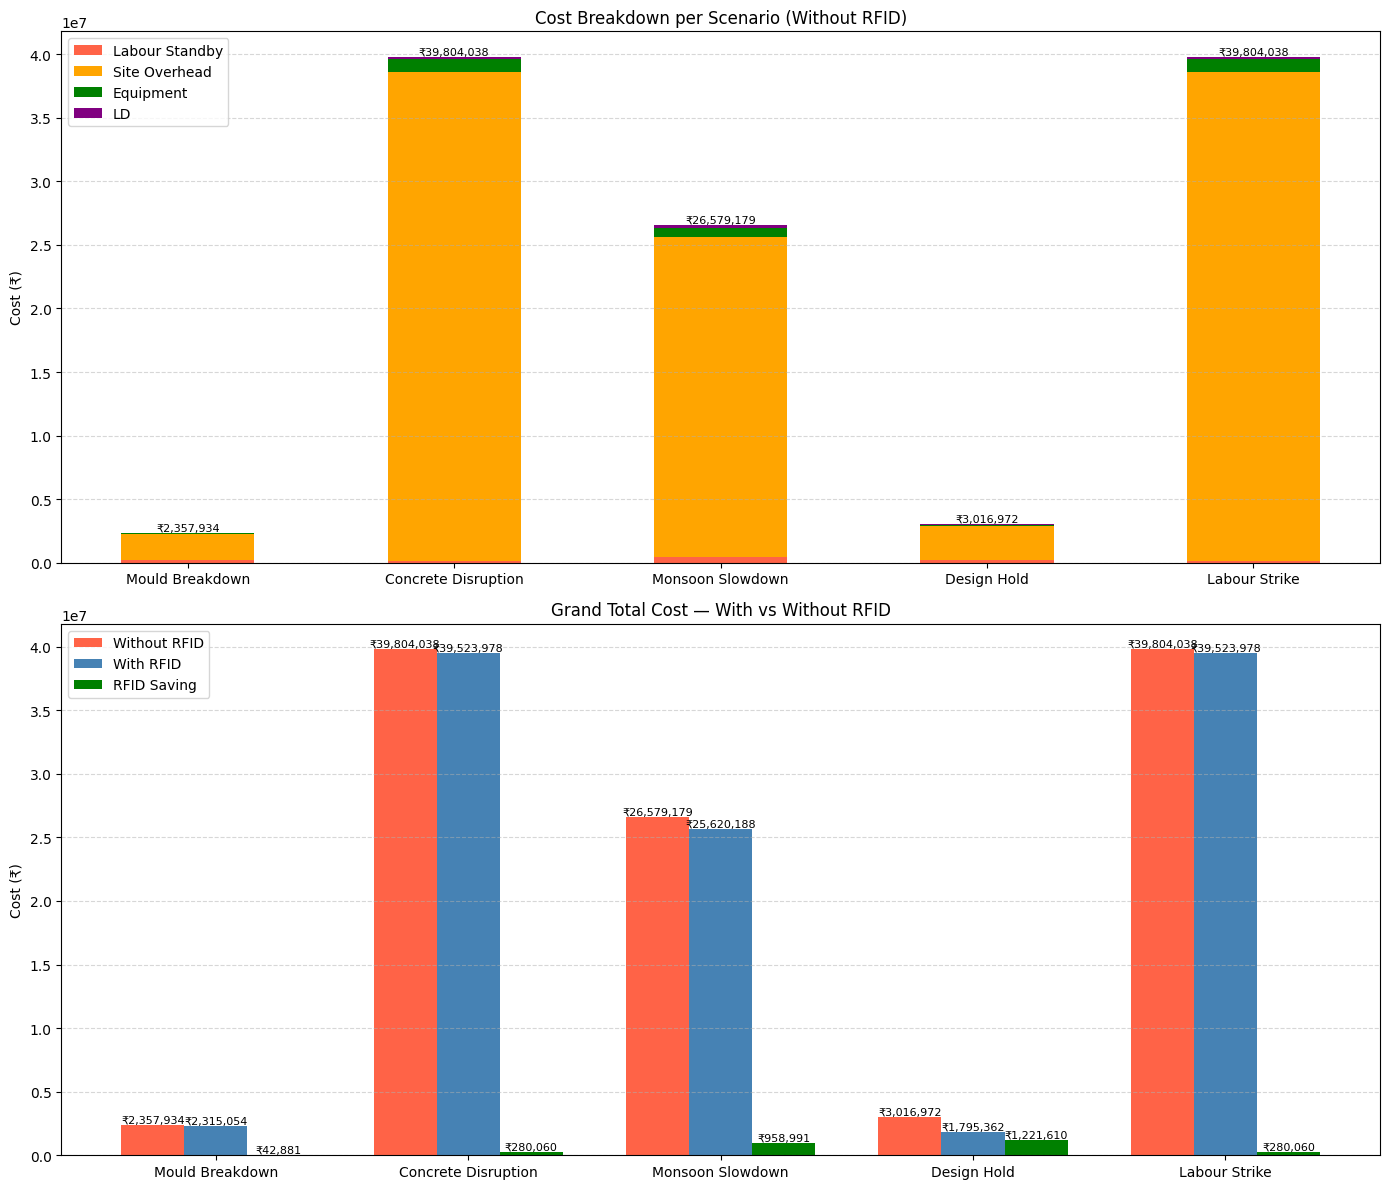

OVERALL COST SUMMARY
Total Labour Cost            : ₹1,200,000
Total Site Overhead          : ₹106,745,562
Total Equipment Cost         : ₹2,976,600
Total LD Cost                : ₹640,000
------------------------------------------------------------
Grand Total without RFID     : ₹111,562,162
Grand Total with RFID        : ₹108,778,560
Total RFID Saving            : ₹2,783,603


In [22]:
import matplotlib.pyplot as plt

# ── Ensure df_results has all necessary columns for plotting ──────────────────
# This section is embedded to ensure the plotting cell is self-sufficient
# and can execute correctly even if preceding data processing cells were skipped.

# From 3gHGtcOp1hLq: Liquidated Damages Calculation
ld_upper_cap = 20000000

def calculate_ld(delay_days):
    ld = 0
    if delay_days <= 0:
        return 0
    slab1_days = min(delay_days, 28)
    ld += slab1_days * 10000
    if delay_days > 28:
        slab2_days = min(delay_days - 28, 28)
        ld += slab2_days * 50000
    if delay_days > 56:
        slab3_days = delay_days - 56
        ld += slab3_days * 100000
    ld = min(ld, ld_upper_cap)
    return ld

if 'Delay (days)' not in df_results.columns:
    df_results['Delay (days)']  = (df_results['Delay (months)'] * days_per_month).round(1)
df_results['LD Cost (₹)']   = df_results['Delay (days)'].apply(lambda x: calculate_ld(int(x)))

# From vVNG0qfe17u1: RFID reduced delay days and LD with RFID
if 'RFID Detection Saving (days)' not in df_results.columns:
    df_results['RFID Detection Saving (days)'] = df_results['Scenario'].map(
        {s: early_detection_hrs[s] / 24 for s in early_detection_hrs}
    )
if 'Delay (days) with RFID' not in df_results.columns:
    df_results['Delay (days) with RFID'] = (df_results['Delay (days)'] -
                                             df_results['RFID Detection Saving (days)']).clip(lower=0).round(1)
df_results['LD Cost with RFID (₹)'] = df_results['Delay (days) with RFID'].apply(lambda x: calculate_ld(int(x)))
df_results['LD Saving by RFID (₹)'] = df_results['LD Cost (₹)'] - df_results['LD Cost with RFID (₹)']

# From -PSXUXqe2whx: Site Overhead Cost
total_project_budget_cr  = 2000
total_project_budget     = total_project_budget_cr * 1e7
project_duration_months  = month_num
project_duration_days    = project_duration_months * days_per_month
site_overhead_pct        = 0.10
total_site_overhead      = total_project_budget * site_overhead_pct
daily_site_overhead      = total_site_overhead / project_duration_days
site_overhead_per_mould_per_day = daily_site_overhead / total_moulds

if 'Site Overhead per day (₹)' not in df_results.columns:
    df_results['Site Overhead per day (₹)'] = site_overhead_per_mould_per_day * df_results['Moulds Down']
df_results['Site Overhead Cost (₹)']    = (df_results['Site Overhead per day (₹)'] *
                                            df_results['Delay (days)'])
df_results['Site Overhead with RFID (₹)'] = (df_results['Site Overhead per day (₹)'] *
                                              df_results['Delay (days) with RFID'])
df_results['Site Overhead Saving by RFID (₹)'] = (df_results['Site Overhead Cost (₹)'] -
                                                    df_results['Site Overhead with RFID (₹)'])

# Update Total Cost with OH
df_results['Total Cost with OH (₹)']      = (df_results['Total Cost (₹)'] +
                                              df_results['Site Overhead Cost (₹)'])
df_results['Total Cost with OH RFID (₹)'] = (df_results['Net Cost RFID (₹)'] +
                                              df_results['Site Overhead with RFID (₹)'])
df_results['Total OH Saving by RFID (₹)'] = (df_results['Total Cost with OH (₹)'] -
                                              df_results['Total Cost with OH RFID (₹)'])

# From ySSt_OAOAoeS: Equipment Standby Cost and Grand Totals
equipment_rates = {
    'Gantry Crane'    : 2000,
    'Batching Plant'  : 1500,
    'Transit Mixer'   : 1000,
    'Form Vibrators'  : 500,
    'Curing System'   : 500,
}
equipment_cost_per_mould_per_day = sum(equipment_rates.values())

df_results['Equipment Cost (₹)']          = (df_results['Moulds Down'] *
                                              df_results['Delay (days)'] *
                                              equipment_cost_per_mould_per_day)
df_results['Equipment Cost with RFID (₹)'] = (df_results['Moulds Down'] *
                                               df_results['Delay (days) with RFID'] *
                                               equipment_cost_per_mould_per_day)
df_results['Equipment Saving by RFID (₹)'] = (df_results['Equipment Cost (₹)'] -
                                               df_results['Equipment Cost with RFID (₹)'])

# Grand Total calculations
df_results['Grand Total Cost (₹)']          = (df_results['Total Cost with OH (₹)'] +
                                               df_results['Equipment Cost (₹)'] +
                                               df_results['LD Cost (₹)'])
df_results['Grand Total with RFID (₹)']     = (df_results['Total Cost with OH RFID (₹)'] +
                                               df_results['Equipment Cost with RFID (₹)'] +
                                               df_results['LD Cost with RFID (₹)'])
df_results['Grand Total Saving by RFID (₹)'] = (df_results['Grand Total Cost (₹)'] -
                                                df_results['Grand Total with RFID (₹)'])

# ── Plotting code starts here ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

scenarios_list = df_results['Scenario'].tolist()
x              = np.arange(len(scenarios_list))
width          = 0.35

# ── Chart 1: Cost Breakdown per Scenario (stacked bar) ───────────────────────
# Removed 'idle_costs' as per user request
labour_costs    = df_results['Labour Cost (₹)'].tolist()
overhead_costs  = df_results['Site Overhead Cost (₹)'].tolist()
equipment_costs = df_results['Equipment Cost (₹)'].tolist()
ld_costs        = df_results['LD Cost (₹)'].tolist()

b2 = axes[0].bar(x, labour_costs,    width=0.5, label='Labour Standby',  color='tomato') # Now the first bar
b3 = axes[0].bar(x, overhead_costs,  width=0.5, label='Site Overhead',   color='orange',
                 bottom=labour_costs)
b4 = axes[0].bar(x, equipment_costs, width=0.5, label='Equipment',       color='green',
                 bottom=[l+o for l,o in zip(labour_costs, overhead_costs)])
b5 = axes[0].bar(x, ld_costs,        width=0.5, label='LD',              color='purple',
                 bottom=[l+o+e for l,o,e in zip(labour_costs, overhead_costs, equipment_costs)])

# Total label on top of each bar
for i, total in enumerate(df_results['Grand Total Cost (₹)']):
    axes[0].text(i, total + 1000, f'₹{total:,.0f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(scenarios_list, rotation=0, ha='center')
axes[0].set_ylabel('Cost (₹)')
axes[0].set_title('Cost Breakdown per Scenario (Without RFID)')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# ── Chart 2: Grand Total With vs Without RFID + Saving ───────────────────────
width = 0.25

bars_without = axes[1].bar(x - width, df_results['Grand Total Cost (₹)'],
                            width, label='Without RFID', color='tomato')
bars_with    = axes[1].bar(x,         df_results['Grand Total with RFID (₹)'],
                            width, label='With RFID',    color='steelblue')
bars_saving  = axes[1].bar(x + width, df_results['Grand Total Saving by RFID (₹)'],
                            width, label='RFID Saving',  color='green')

for bar in bars_without:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)
for bar in bars_with:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)
for bar in bars_saving:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

axes[1].set_xticks(x)
axes[1].set_xticklabels(scenarios_list, rotation=0, ha='center')
axes[1].set_ylabel('Cost (₹)')
axes[1].set_title('Grand Total Cost — With vs Without RFID')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('cost_breakdown_summary.png', dpi=150)
plt.show()

# ── Overall summary ───────────────────────────────────────────────────────────
print("=" * 60)
print("OVERALL COST SUMMARY")
print("=" * 60)
# Removed 'Total Idle Cost' from summary
print(f"Total Labour Cost            : ₹{df_results['Labour Cost (₹)'].sum():,.0f}")
print(f"Total Site Overhead          : ₹{df_results['Site Overhead Cost (₹)'].sum():,.0f}")
print(f"Total Equipment Cost         : ₹{df_results['Equipment Cost (₹)'].sum():,.0f}")
print(f"Total LD Cost                : ₹{df_results['LD Cost (₹)'].sum():,.0f}")
print("-" * 60)
print(f"Grand Total without RFID     : ₹{df_results['Grand Total Cost (₹)'].sum():,.0f}")
print(f"Grand Total with RFID        : ₹{df_results['Grand Total with RFID (₹)'].sum():,.0f}")
print(f"Total RFID Saving            : ₹{df_results['Grand Total Saving by RFID (₹)'].sum():,.0f}")
print("=" * 60)

In [26]:
# ── Export to Excel ───────────────────────────────────────────────────────────
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

output_path = 'idle_cost_analysis.xlsx'

# Define typical_ratio and pier_ej_ratio if not already defined (to avoid NameError)
typical_ratio = typical_segments / total_segments
pier_ej_ratio = pier_ej_segments / total_segments

# ── Rename columns with formula descriptions ──────────────────────────────────
column_descriptions = {
    'Scenario'                          : 'Scenario',
    'Duration (months)'                 : 'Duration (months) [User Defined]',
    'Moulds Down'                       : 'Moulds Down [User Defined]',
    'Lost Segments'                     : 'Lost Segments [Moulds Down × Seg/Mould/Month × Duration]',
    'Delay (days)'                      : 'Delay (days) [Lost Segments / Full Capacity × 30]',
    'Idle Cost (₹)'                     : 'Idle Cost (₹) [Moulds Down × Delay Days × ₹10,000/day]',
    'Labour Cost (₹)'                   : 'Labour Cost (₹) [Delay Days × ₹400/hr × 20hrs]',
    'Site Overhead Cost (₹)'            : 'Site Overhead (₹) [Moulds Down × Delay Days × OH/Mould/Day]',
    'Equipment Cost (₹)'                : 'Equipment Cost (₹) [Moulds Down × Delay Days × ₹5,500/day]',
    'LD Cost (₹)'                       : 'LD Cost (₹) [Slab1: ₹10k/day(1-28), Slab2: ₹50k/day(29-56), Slab3: ₹1L/day(57+), Cap: ₹200Cr]',
    'Grand Total Cost (₹)'              : 'Grand Total (₹) [Idle + Labour + Overhead + Equipment + LD]',
    'RFID Detection Saving (days)'      : 'RFID Early Detection (days) [Detection Hrs / 24]',
    'Delay (days) with RFID'            : 'Delay Days with RFID [Delay Days - RFID Detection Days]',
    'RFID Saving (₹)'                   : 'RFID Saving - Idle (₹) [Moulds Down × Detection Days × ₹10,000]',
    'LD Saving by RFID (₹)'             : 'RFID Saving - LD (₹) [LD Cost - LD Cost with RFID]',
    'Site Overhead Saving by RFID (₹)'  : 'RFID Saving - Overhead (₹) [OH Cost - OH Cost with RFID]',
    'Equipment Saving by RFID (₹)'      : 'RFID Saving - Equipment (₹) [Equip Cost - Equip Cost with RFID]',
    'Grand Total with RFID (₹)'         : 'Grand Total with RFID (₹) [Grand Total - All RFID Savings]',
    'Grand Total Saving by RFID (₹)'    : 'Total RFID Saving (₹) [Grand Total - Grand Total with RFID]',
}

# ── Apply renaming and export ─────────────────────────────────────────────────
cols_to_export = [c for c in column_descriptions.keys() if c in df_results.columns]
df_export      = df_results[cols_to_export].rename(columns=column_descriptions)

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    assumptions.to_excel(writer, sheet_name='Assumptions',        index=False)
    df_timeline.to_excel(writer, sheet_name='Base Plan',          index=False)
    df_export.to_excel(  writer, sheet_name='Scenario Analysis',  index=False)
    summary.to_excel(    writer, sheet_name='Cost Summary',       index=False)

print(f"Excel exported : {output_path}")

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:

    # ── Sheet 1: Assumptions ──────────────────────────────────────────────────
    assumptions = pd.DataFrame({
        'Parameter': [
            'Total Segments', 'Typical Ratio', 'Pier/EJ Ratio',
            'Typical Cycle (hrs)', 'Pier/EJ Cycle (hrs)',
            'Shift Hours/Day', 'Days/Month', 'Total Moulds',
            'Typical Moulds', 'Pier Moulds',
            'Labour Cost/Day (₹)',
            'Equipment Cost/Mould/Day (₹)', 'Site Overhead %',
            'Total Project Budget (₹ Cr)', 'LD Cap (₹ Cr)',
        ],
        'Value': [
            total_segments, typical_ratio, pier_ej_ratio,
            typical_cycle_hrs, pier_ej_cycle_hrs,
            shift_hrs_per_day, days_per_month, total_moulds,
            typical_moulds, pier_moulds,
            labour_cost_per_day,
            equipment_cost_per_mould_per_day, site_overhead_pct * 100,
            total_project_budget_cr, ld_upper_cap / 1e7,
        ]
    })
    assumptions.to_excel(writer, sheet_name='Assumptions', index=False)

    # ── Sheet 2: Base Plan ────────────────────────────────────────────────────
    df_timeline.to_excel(writer, sheet_name='Base Plan', index=False)

    # ── Sheet 3: Scenario Analysis ────────────────────────────────────────────
    df_results.to_excel(writer, sheet_name='Scenario Analysis', index=False)

    # ── Sheet 4: Cost Summary ─────────────────────────────────────────────────
    summary = pd.DataFrame({
        'Cost Component'  : ['Labour Cost', 'Site Overhead',
                             'Equipment Cost', 'LD Cost',
                             'Grand Total without RFID',
                             'Grand Total with RFID',
                             'Total RFID Saving'],
        'Amount (₹)'      : [
            df_results['Labour Cost (₹)'].sum(),
            df_results['Site Overhead Cost (₹)'].sum(),
            df_results['Equipment Cost (₹)'].sum(),
            df_results['LD Cost (₹)'].sum(),
            df_results['Grand Total Cost (₹)'].sum(),
            df_results['Grand Total with RFID (₹)'].sum(),
            df_results['Grand Total Saving by RFID (₹)'].sum(),
        ]
    })
    summary.to_excel(writer, sheet_name='Cost Summary', index=False)

print(f"Excel exported successfully : {output_path}")

Excel exported : idle_cost_analysis.xlsx
Excel exported successfully : idle_cost_analysis.xlsx


In [27]:
from google.colab import files
files.download('idle_cost_analysis.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>